# Telecom Customer Churn Analysis

## 04: Multivariate Analysis and Customer Churn

### Objective

This notebook investigates how multiple customer characteristics, service usage patterns, and account factors interact in relation to customer churn.

The analysis focuses on:

- Examining how tenure and contract type interact in relation to churn
- Investigating how internet type, service subscriptions, and billing characteristics relate to churn when considered together
- Exploring how customer profile characteristics and tenure interact with churn
- Examining the relationship between offers, customer tenure, and churn
- Identifying combined patterns that may provide additional insight beyond individual bivariate relationships

This builds on the bivariate analysis by examining multiple variables together to better understand how customer characteristics and behaviors interact in relation to churn.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Load cleaned dataset from first notebook
churn_df = pd.read_parquet('../data/processed/telecom_customer_churn_clean.parquet')

In [3]:
# Set visualization settings
sns.set_theme(style='white', 
              context='notebook', 
              palette='deep')

plt.rcParams['figure.figsize'] = (5, 3)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 16
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelpad'] = 6
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

### Contract and Product Risk Interactions
- Is high Fiber Optic churn universal across the product line, or is it strictly concentrated among Month-to-Month subscribers?
- How efficiently do multi-year contractual commitments neutralize the retention risks associated with different internet technologies?

In [12]:
churn_analysis_df = churn_df[churn_df['Customer Status'].isin(['Churned', 'Stayed'])].copy()
churn_analysis_df['Is Churned'] = churn_analysis_df['Customer Status'].map({
    'Churned': 1,
    'Stayed': 0
})

churn_analysis_df['Customer Status'] = churn_analysis_df['Customer Status'].cat.remove_unused_categories()

internet_contract_churn = churn_analysis_df.pivot_table(
    index='Internet Type',
    columns='Contract',
    values='Is Churned',
    aggfunc='mean'
) * 100

internet_contract_churn.style.format('{:.1f}%').background_gradient(cmap='Reds', axis=None)

Contract,Month-to-Month,One Year,Two Year
Internet Type,,,
Cable,50.6%,12.3%,1.4%
DSL,38.3%,9.2%,2.0%
Fiber Optic,61.7%,17.1%,5.7%
None,27.4%,2.6%,0.8%


### Financial and Customer Lifecycle Interactions
- Where on the combined spectrum of monthly cost and customer lifetime does the acute churn "danger zone" lie?
- Does early onboarding attrition occur equally across all billing tiers or is it heavily concentrated in high-cost service pacakages?

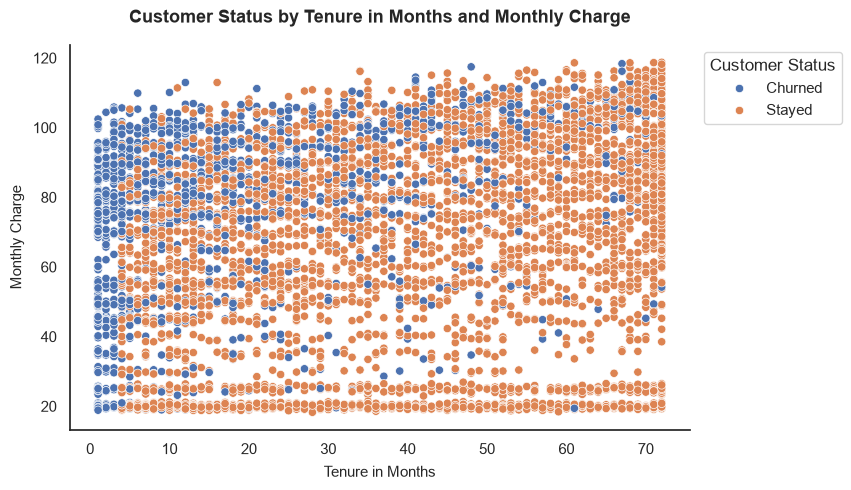

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=churn_analysis_df,
    x='Tenure in Months',
    y='Monthly Charge',
    hue='Customer Status'
)

plt.title('Customer Status by Tenure in Months and Monthly Charge')
plt.legend(bbox_to_anchor=(1.01, 1), title='Customer Status');

In [23]:
early_churners = churn_analysis_df[
    (churn_analysis_df['Tenure in Months'] <= 12) & 
    (churn_analysis_df['Customer Status'] == 'Churned')
]

early_churners['Monthly Charge'].describe()

count    1017.000000
mean       66.729462
std        24.139198
min        18.850000
25%        48.750000
50%        74.099998
75%        84.800003
max       112.949997
Name: Monthly Charge, dtype: float64

### Behavioral Anchoring and Household Interactions
- Does the adoption of multiple value-added services protect high-risk, single-person households from churning as effectively as family accounts?
- How does the relationship between product depth (number of add-ons) and retention vary across different household living structures?

In [30]:
internet_customers_df = churn_analysis_df[churn_analysis_df['Internet Service'] == 1].copy()

addon_cols = ['Unlimited Data', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support']
internet_customers_df['Addons Count'] = internet_customers_df[addon_cols].sum(axis=1)

internet_customers_df['Household Type'] = (
    internet_customers_df['Married'].astype(int).astype(str) + (internet_customers_df['Number of Dependents'] >= 1).astype(int).astype(str)
)

internet_customers_df['Household Type']

0       10
1       00
2       10
3       10
4       01
        ..
6916    00
6918    00
6919    10
6921    10
6922    10
Name: Household Type, Length: 5155, dtype: str

In [39]:
hhtype_addons_churn = internet_customers_df.pivot_table(
    index='Household Type',
    columns='Addons Count',
    values='Is Churned',
    aggfunc='mean'
) * 100

hhtype_addons_churn = hhtype_addons_churn.round(1)

hhtype_addons_churn.style.format('{:.1f}%')

Addons Count,0,1,2,3,4,5
Household Type,,,,,,
00,70.1%,65.7%,45.4%,26.7%,17.5%,9.3%
01,40.0%,60.5%,19.1%,19.1%,0.0%,0.0%
10,55.3%,65.3%,40.2%,33.0%,13.4%,5.7%
11,0.0%,14.0%,9.5%,4.5%,1.0%,0.9%


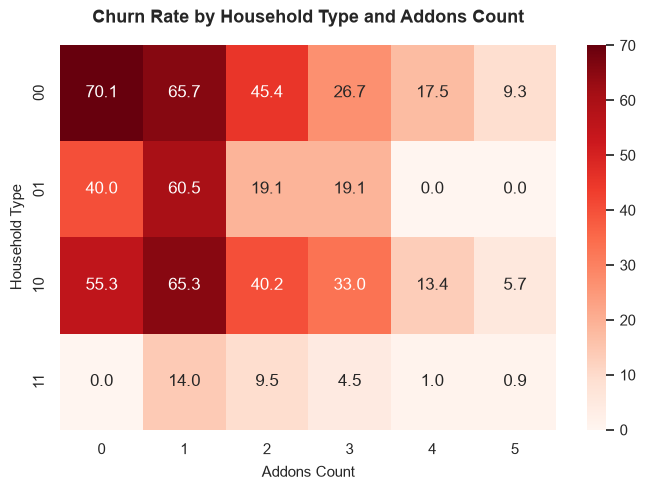

In [40]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    hhtype_addons_churn,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.xlabel('Addons Count')
plt.ylabel('Household Type')
plt.title('Churn Rate by Household Type and Addons Count')
plt.show()

### Competitive Vulnerability by Product Tier
- Are customer losses attributed to competitor offerings driven by higher monthly billing amounts with specific internet connection types?
- How do the price distributions of customer sciting "Competitor" or "Price" compare across Fiber Optic, DSL, and Cable lines?

# Summaries
- - Fiber Optic churn is not universal. It is heavily concentrated among Month-to-Month subscribers at 61.7% and drops sharply to 17.1% on One-Year and 5.7% on Two-Year agreements.
- Multi-year contractual commitments neutralize retention risks with extreme efficiency, reducing attrition by over 90% across every internet technology and bringing churn rates down to just 0.8%–5.7% on Two-Year terms.



- The acute churn "danger zone" lies in the first 12 months of customer tenure, where over 1,000 customers canceled their service.
- On the monthly cost spectrum, this danger zone is heavily concentrated between $48.75 and $84.80 per month (the 25th to 75th percentiles), peaking around a median bill of $74.10.
- Customers paying under $48.75/month or surviving past the first year are significantly less likely to churn.